In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv('telecom_ibm_feature_engineered.csv')
print(df.shape)

(7043, 43)


In [3]:
print(df['TotalCharges'].describe())

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64


In [4]:
drop_cols = [
    'customerID', 'Name', 'Churn', 'Churn_Binary', 'TotalCharges',
    'TenureGroup', 'CustomerSegment', 'gender', 'Partner',
    'Dependents', 'PhoneService', 'PaperlessBilling',
    'tenure'
    
]
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df['TotalCharges']

print(X.shape, y.shape)
print(X.select_dtypes(include='object').columns.tolist()) 

(7043, 30) (7043,)
[]


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)

Eğitim seti: (5634, 30)
Test seti: (1409, 30)


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
lin_model = LinearRegression()

cv_scores_lin = cross_val_score(lin_model, X_train_scaled, y_train, cv=5, scoring='r2')
print("Linear Regression - CV Ortalama R²:", cv_scores_lin.mean().round(4))

lin_model.fit(X_train_scaled, y_train)
y_pred_lin = lin_model.predict(X_test_scaled)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
mae_lin = mean_absolute_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("Test RMSE:", round(rmse_lin, 2))
print("Test MAE:", round(mae_lin, 2))
print("Test R²:", round(r2_lin, 4))

Linear Regression - CV Ortalama R²: 0.7452
Test RMSE: 1122.49
Test MAE: 883.11
Test R²: 0.7578


In [8]:
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42)

cv_scores_rf_reg = cross_val_score(rf_reg_model, X_train, y_train, cv=5, scoring='r2')
print("Random Forest Regressor - CV Ortalama R²:", cv_scores_rf_reg.mean().round(4))

rf_reg_model.fit(X_train, y_train)
y_pred_rf_reg = rf_reg_model.predict(X_test)

rmse_rf_reg = np.sqrt(mean_squared_error(y_test, y_pred_rf_reg))
mae_rf_reg = mean_absolute_error(y_test, y_pred_rf_reg)
r2_rf_reg = r2_score(y_test, y_pred_rf_reg)

print("Test RMSE:", round(rmse_rf_reg, 2))
print("Test MAE:", round(mae_rf_reg, 2))
print("Test R²:", round(r2_rf_reg, 4))

Random Forest Regressor - CV Ortalama R²: 0.7715
Test RMSE: 1067.84
Test MAE: 762.34
Test R²: 0.7808


In [9]:
revenue_model_results = pd.DataFrame({
    'ModelName': ['Linear Regression', 'Random Forest Regressor'],
    'Algorithm': ['LinearRegression', 'RandomForestRegressor'],
    'CV_R2': [cv_scores_lin.mean(), cv_scores_rf_reg.mean()],
    'Test_RMSE': [rmse_lin, rmse_rf_reg],
    'Test_MAE': [mae_lin, mae_rf_reg],
    'Test_R2': [r2_lin, r2_rf_reg],
    'TrainDate': pd.Timestamp.now().strftime('%Y-%m-%d')
})

revenue_model_results.to_csv('revenue_model_performance.csv', index=False)
revenue_model_results

,ModelName,Algorithm,CV_R2,Test_RMSE,Test_MAE,Test_R2,TrainDate
0,Linear Regression,LinearRegression,0.745157,1122.486635,883.107026,0.757809,2026-07-10
1,Random Forest Regressor,RandomForestRegressor,0.771532,1067.840403,762.340221,0.780816,2026-07-10


In [10]:
test_customer_ids = df.loc[X_test.index, 'customerID']

revenue_predictions = pd.DataFrame({
    'CustomerId': test_customer_ids,
    'ActualRevenue': y_test.values,
    'PredictedRevenue': y_pred_rf_reg.round(2)  # daha iyi çıkan modele göre güncellenecek
})

revenue_predictions.to_csv('revenue_predictions.csv', index=False)
revenue_predictions.head(10)

,CustomerId,ActualRevenue,PredictedRevenue
185,1024-GUALD,24.80,448.52
2715,0484-JPBRU,996.45,239.27
3825,3620-EHIMZ,1031.70,547.96
1807,6910-HADCM,76.35,531.53
132,8587-XYZSF,3260.10,2838.91
1263,6818-WOBHJ,6127.60,4067.57
3732,3082-YVEKW,1759.40,4987.23
1672,4737-AQCPU,5016.65,4262.11
811,4853-RULSV,7250.15,6995.36
2526,5766-ZJYBB,19.40,85.34


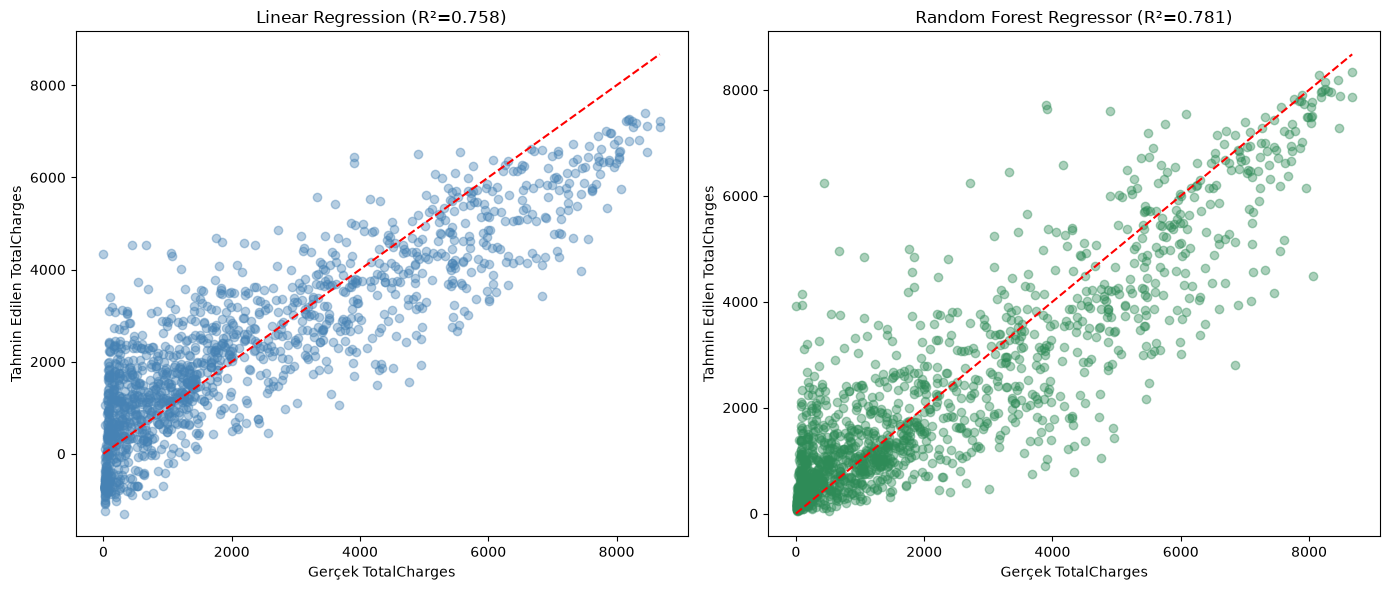

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred_lin, alpha=0.4, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Gerçek TotalCharges')
axes[0].set_ylabel('Tahmin Edilen TotalCharges')
axes[0].set_title(f'Linear Regression (R²={r2_lin:.3f})')

axes[1].scatter(y_test, y_pred_rf_reg, alpha=0.4, color='seagreen')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Gerçek TotalCharges')
axes[1].set_ylabel('Tahmin Edilen TotalCharges')
axes[1].set_title(f'Random Forest Regressor (R²={r2_rf_reg:.3f})')

plt.tight_layout()
plt.savefig('revenue_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

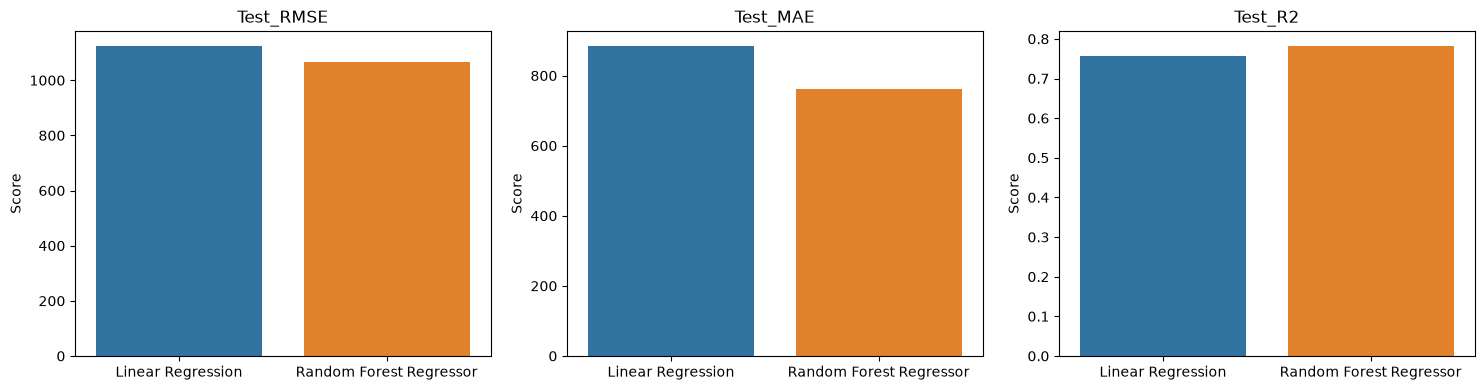

In [12]:
metrics_to_plot = ['Test_RMSE', 'Test_MAE', 'Test_R2']
plot_data = revenue_model_results.melt(id_vars='ModelName', value_vars=metrics_to_plot,
                                          var_name='Metric', value_name='Score')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, metric in enumerate(metrics_to_plot):
    subset = plot_data[plot_data['Metric'] == metric]
    sns.barplot(data=subset, x='ModelName', y='Score', hue='ModelName', ax=axes[i], legend=False)
    axes[i].set_title(metric)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('revenue_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

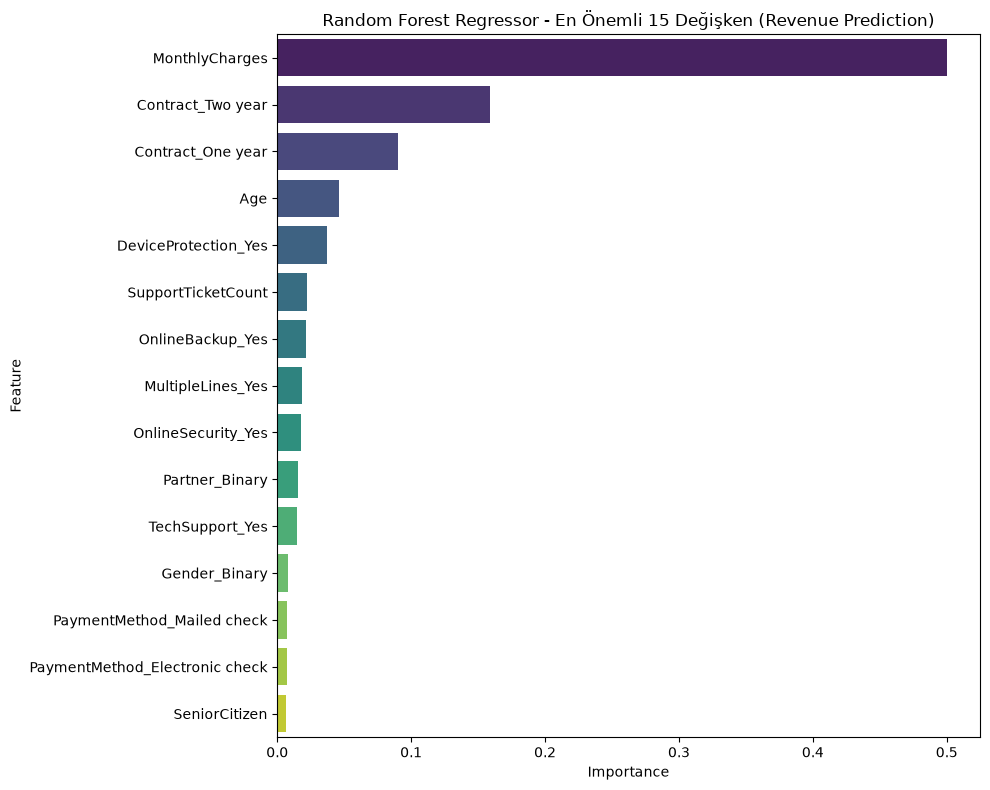

In [13]:
importances_reg = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_reg_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances_reg, y='Feature', x='Importance', hue='Feature', palette='viridis', legend=False)
plt.title('Random Forest Regressor - En Önemli 15 Değişken (Revenue Prediction)')
plt.tight_layout()
plt.savefig('revenue_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
import joblib

joblib.dump(lin_model, 'revenue_model_linear.pkl')
joblib.dump(rf_reg_model, 'revenue_model_rf.pkl')
joblib.dump(scaler, 'revenue_scaler.pkl')
print("Modeller kaydedildi.")

Modeller kaydedildi.
